In [1]:
import numpy as np
from scripts.VectorFieldEmbedder import VectorFieldEmbedder

# -----------------------------
# DATASET REGISTRY (your paths)
# -----------------------------
DATASETS = {
    "cell_cycle": {
        "X": "./data/real_data_benchmark/cell_cycle/X_cc.npy",
        "V": "./data/real_data_benchmark/cell_cycle/V_cc.npy",
        "color": "./data/real_data_benchmark/cell_cycle/color_cell_cycle_relativePos.npy",
        "embedding": "./data/real_data_benchmark/cell_cycle/flowmap_embedding.npy",
    },
    "pancreas": {
        "X": "./data/real_data_benchmark/pancreas/X_pca.npy",
        "V": "./data/real_data_benchmark/pancreas/V_pca_stochastic.npy",
        "color": "./data/real_data_benchmark/pancreas/color_clusters.npy",
        "embedding": "./data/real_data_benchmark/pancreas/scvelo_umap_embedding.npy",
    },
    "dentate_gyrus": {
        "X": "./data/real_data_benchmark/dentate_gyrus/X_pca.npy",
        "V": "./data/real_data_benchmark/dentate_gyrus/V_pca_stochastic.npy",
        "color": "./data/real_data_benchmark/dentate_gyrus/color_clusters.npy",
        "embedding": "./data/real_data_benchmark/dentate_gyrus/scvelo_umap_embedding.npy",
    },
    "larry": {
        "X": "./data/real_data_benchmark/larry/X_raw.npy",
        "V": "./data/real_data_benchmark/larry/V_raw.npy",
        "color": "./data/real_data_benchmark/larry/color_state.npy",
        "embedding": "./data/real_data_benchmark/larry/flowmap_embedding.npy",
    },
}

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
from manfit_velocity import VelocityManifoldFitter

X = np.load(DATASETS["cell_cycle"]["X"])
V = np.load(DATASETS["cell_cycle"]["V"])
X_emb = np.load(DATASETS["cell_cycle"]["embedding"])
color = np.load(DATASETS["cell_cycle"]["color"])

solver = VelocityManifoldFitter(
    Y=X,
    W=V,
    k=30,
    d=2,
    alpha=0.8,
    h=0.4,
    T=20,
    theta=0.8,
    use_abs_cos=True,
    recompute_neighbors=False
)

X_fit = solver.fit(eta=0.2, mode="weighted")
V_fit = solver.v

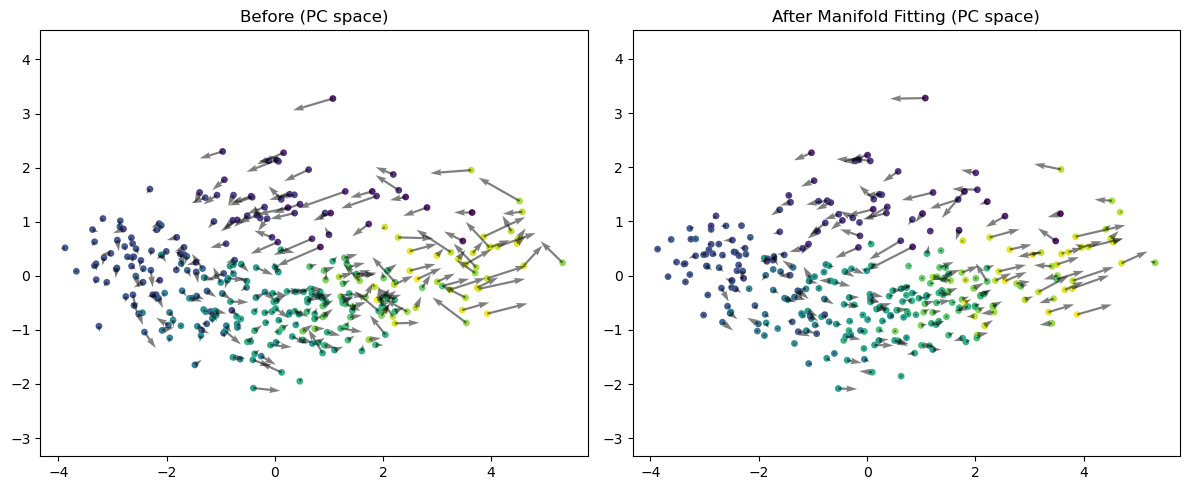

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ----------------------------
# PCA (fit on original X)
# ----------------------------
pca = PCA(n_components=2)
X_pc = pca.fit_transform(X)
X_fit_pc = pca.transform(X_fit)

# project velocity using same PCA
V_pc = V @ pca.components_.T
V_fit_pc = V_fit @ pca.components_.T

# ----------------------------
# Subsample
# ----------------------------
np.random.seed(0)
idx = np.random.choice(X.shape[0], size=300, replace=False)

X_pc_sub = X_pc[idx]
V_pc_sub = V_pc[idx]

X_fit_pc_sub = X_fit_pc[idx]
V_fit_pc_sub = V_fit_pc[idx]

color_sub = color[idx]

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- BEFORE ---
axes[0].scatter(
    X_pc_sub[:, 0], X_pc_sub[:, 1],
    c=color_sub, s=15, cmap="viridis", alpha=0.9
)

axes[0].quiver(
    X_pc_sub[:, 0], X_pc_sub[:, 1],
    V_pc_sub[:, 0], V_pc_sub[:, 1],
    color="black",
    alpha=0.5,
    scale=100,
    width=0.004
)

axes[0].set_title("Before (PC space)")
axes[0].axis("equal")


# --- AFTER ---
axes[1].scatter(
    X_fit_pc_sub[:, 0], X_fit_pc_sub[:, 1],
    c=color_sub, s=15, cmap="viridis", alpha=0.9
)

axes[1].quiver(
    X_fit_pc_sub[:, 0], X_fit_pc_sub[:, 1],
    V_fit_pc_sub[:, 0], V_fit_pc_sub[:, 1],
    color="black",
    alpha=0.5,
    scale=100,
    width=0.004
)

axes[1].set_title("After Manifold Fitting (PC space)")
axes[1].axis("equal")

plt.tight_layout()
plt.show()

In [40]:
import matplotlib.pyplot as plt
from flowmap.flowmap_embedding import VectorFieldEmbedder
from flowmap.plot import plot_velocity_stream

# -----------------------------
# BEFORE
# -----------------------------
emb_before = VectorFieldEmbedder(
    X, V,
    X_emb=X_emb,
    dist_method="phase",
    use_PCA=False,
    dof=30,
    method="umap",
    knn_k=30,
)

emb_before.fit_embedding(seed=0)   # <-- unified API

# -----------------------------
# AFTER
# -----------------------------
emb_after = VectorFieldEmbedder(
    X_fit, V_fit,
    X_emb=X_emb,
    dist_method="phase",
    use_PCA=False,
    dof=30,
    method="umap",
    knn_k=30,
)

emb_after.fit_embedding(seed=0)

[Spline] Fitting manifold spline on 2793 cells …
[Spline] Using all 2793 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 2793 points as control points.
[FlowMap] Done.
[Spline] Fitting manifold spline on 2793 cells …
[Spline] Using all 2793 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 2793 points as control points.
[FlowMap] Done.


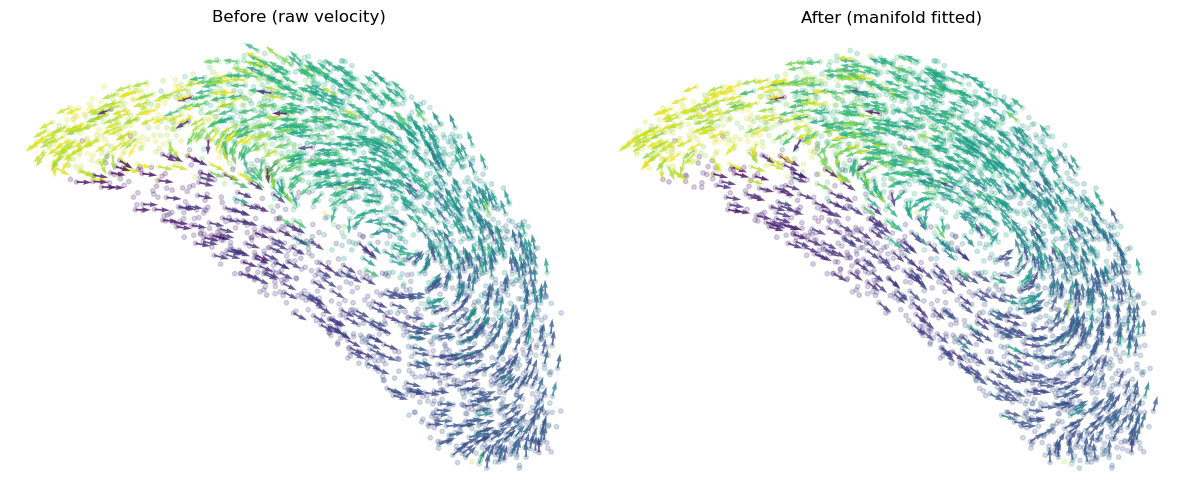

In [45]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# helper (clean quiver)
# -------------------------
def plot_quiver(ax, X, V, color, title):
    # normalize color
    c = (color - color.min()) / (color.max() - color.min() + 1e-12)

    # subsample (important for readability)
    n = len(X)
    idx = np.random.choice(n, size=min(1000, n), replace=False)

    Xs = X[idx]
    Vs = V[idx]
    cs = c[idx]

    # optional: normalize vectors (direction > magnitude)
    Vs = Vs / (np.linalg.norm(Vs, axis=1, keepdims=True) + 1e-12)

    ax.scatter(
        X[:, 0], X[:, 1],
        c=c, cmap="viridis",
        s=10, alpha=0.2
    )

    ax.quiver(
        Xs[:, 0], Xs[:, 1],
        Vs[:, 0], Vs[:, 1],
        color=plt.cm.viridis(cs),
        angles='xy',
        scale_units='xy',
        scale=3,
        width=0.003,
        alpha=0.8
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


# -------------------------
# BEFORE
# -------------------------
plot_quiver(
    axs[0],
    emb_before.X_emb,
    emb_before.V_emb if hasattr(emb_before, "V_emb") else emb_before.V,
    color,
    "Before (raw velocity)"
)

# -------------------------
# AFTER
# -------------------------
plot_quiver(
    axs[1],
    emb_after.X_emb,
    emb_after.V_emb if hasattr(emb_after, "V_emb") else emb_after.V,
    color,
    "After (manifold fitted)"
)

plt.tight_layout()
plt.show()

In [26]:
from manfit_velocity import VelocityManifoldFitter

X = np.load(DATASETS["pancreas"]["X"])
V = np.load(DATASETS["pancreas"]["V"])
X_emb = np.load(DATASETS["pancreas"]["embedding"])
color = np.load(DATASETS["pancreas"]["color"])

solver = VelocityManifoldFitter(
    Y=X,
    W=V,
    k=30,
    d=2,
    alpha=0.8,
    h=0.4,
    T=20,
    theta=0.8,
    use_abs_cos=True,
    recompute_neighbors=False
)

X_fit = solver.fit(eta=0.2, mode="weighted")
V_fit = solver.v

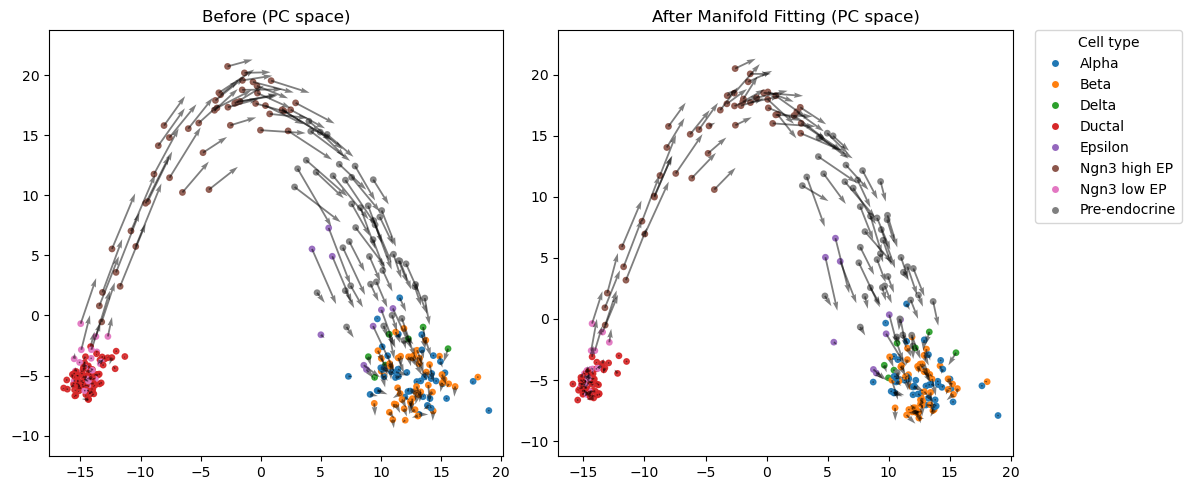

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ----------------------------
# PCA (fit on original X)
# ----------------------------
pca = PCA(n_components=2)
X_pc = pca.fit_transform(X)
X_fit_pc = pca.transform(X_fit)

# project velocity using same PCA
V_pc = V @ pca.components_.T
V_fit_pc = V_fit @ pca.components_.T

# ----------------------------
# Subsample
# ----------------------------
np.random.seed(0)
idx = np.random.choice(X.shape[0], size=300, replace=False)

X_pc_sub = X_pc[idx]
V_pc_sub = V_pc[idx]

X_fit_pc_sub = X_fit_pc[idx]
V_fit_pc_sub = V_fit_pc[idx]

color_sub = color[idx]

# ----------------------------
# Build discrete color map
# ----------------------------
unique_labels = np.unique(color_sub)
n_labels = len(unique_labels)

cmap = plt.get_cmap("tab10") if n_labels <= 10 else plt.get_cmap("tab20")

color_map = {lab: cmap(i % cmap.N) for i, lab in enumerate(unique_labels)}
colors_plot = np.array([color_map[c] for c in color_sub])

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- BEFORE ---
axes[0].scatter(
    X_pc_sub[:, 0], X_pc_sub[:, 1],
    c=colors_plot, s=15, alpha=0.9
)

axes[0].quiver(
    X_pc_sub[:, 0], X_pc_sub[:, 1],
    V_pc_sub[:, 0], V_pc_sub[:, 1],
    color="black",
    alpha=0.5,
    scale=4,
    width=0.004
)

axes[0].set_title("Before (PC space)")
axes[0].axis("equal")

# --- AFTER ---
axes[1].scatter(
    X_fit_pc_sub[:, 0], X_fit_pc_sub[:, 1],
    c=colors_plot, s=15, alpha=0.9
)

axes[1].quiver(
    X_fit_pc_sub[:, 0], X_fit_pc_sub[:, 1],
    V_fit_pc_sub[:, 0], V_fit_pc_sub[:, 1],
    color="black",
    alpha=0.5,
    scale=4,
    width=0.004
)

axes[1].set_title("After Manifold Fitting (PC space)")
axes[1].axis("equal")

# ----------------------------
# Legend
# ----------------------------
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[lab], markersize=6, label=str(lab))
    for lab in unique_labels
]

axes[1].legend(
    handles=handles,
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

In [16]:
# import matplotlib.pyplot as plt
# from flowmap.flowmap_embedding import VectorFieldEmbedder
# from flowmap.plot import plot_velocity_stream

# # -----------------------------
# # BEFORE
# # -----------------------------
# emb_before = VectorFieldEmbedder(
#     X, V,
#     X_emb=X_emb,
#     dist_method="phase",
#     use_PCA=True,
#     dof=30,
#     method="umap",
#     knn_k=30,
# )

# emb_before.fit_embedding(seed=0)   # <-- unified API

# # -----------------------------
# # AFTER
# # -----------------------------
# emb_after = VectorFieldEmbedder(
#     X_fit, V_fit,
#     X_emb=X_emb,
#     dist_method="phase",
#     use_PCA=True,
#     dof=30,
#     method="umap",
#     knn_k=30,
# )

# emb_after.fit_embedding(seed=0)

[Spline] Fitting manifold spline on 3696 cells …
[Spline] Using all 3696 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 3696 points as control points.
[FlowMap] Done.
[Spline] Fitting manifold spline on 3696 cells …
[Spline] Using all 3696 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 3696 points as control points.
[FlowMap] Done.


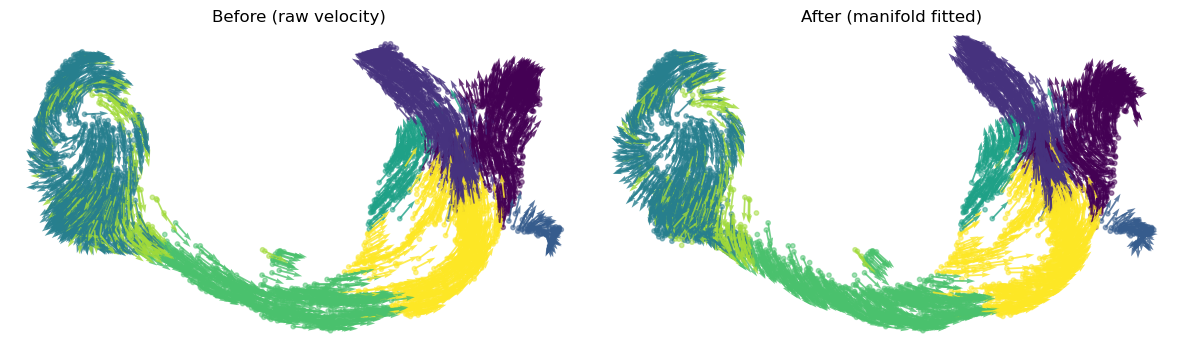

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# helper (clean quiver)
# -------------------------
def plot_quiver(ax, X, V, color, title):
    # categorical → integer → normalize
    c = np.unique(color, return_inverse=True)[1]
    c = c / (c.max() + 1e-12)

    # subsample
    n = len(X)
    idx = np.random.choice(n, size=min(3000, n), replace=False)

    Xs = X[idx]
    Vs = V[idx]
    cs = c[idx]

    # normalize vectors
    Vs = Vs / (np.linalg.norm(Vs, axis=1, keepdims=True) + 1e-12)

    ax.scatter(
        X[:, 0], X[:, 1],
        c=c, cmap="viridis",
        s=10, alpha=0.5
    )

    ax.quiver(
        Xs[:, 0], Xs[:, 1],
        Vs[:, 0], Vs[:, 1],
        color=plt.cm.viridis(cs),
        angles='xy',
        scale_units='xy',
        scale=1,
        width=0.003,
        alpha=0.8
    )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


# -------------------------
# BEFORE
# -------------------------
plot_quiver(
    axs[0],
    emb_before.X_emb,
    emb_before.V_emb if hasattr(emb_before, "V_emb") else emb_before.V,
    color,
    "Before (raw velocity)"
)

# -------------------------
# AFTER
# -------------------------
plot_quiver(
    axs[1],
    emb_after.X_emb,
    emb_after.V_emb if hasattr(emb_after, "V_emb") else emb_after.V,
    color,
    "After (manifold fitted)"
)

plt.tight_layout()
plt.show()